# Analisi statistica e modellazione markoviana del trauma pelvico

Notebook di supporto alla tesi *"Introduzione di modelli markoviani e tecniche di apprendimento per l'analisi delle fratture pelviche"*.

Il notebook è organizzato seguendo la struttura dei capitoli della tesi:

- **Capitolo 2** — Descrizione del campione e Analisi Esplorativa dei Dati (EDA)
- **Capitolo 3** — Selezione dei predittori tramite regressione LASSO
- **Capitolo 4** — Definizione degli stati clinici e vettore di distribuzione iniziale π₀
- **Capitolo 5** — Validazione del modello (Cross-Validation) e Matrice di Transizione

> Nota: il dataset viene caricato e ripulito **una sola volta** all'inizio (Sezione 0). Tutti i capitoli successivi riutilizzano lo stesso DataFrame già pulito, evitando le ricariche/ripuliture ripetute presenti nello script originale.

## 0. Setup e caricamento dati

Importiamo le librerie necessarie e carichiamo il dataset una sola volta.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LassoCV, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, cross_val_score

# Impostazioni grafiche globali
plt.rcParams.update({
    'font.size': 10,
    'axes.labelweight': 'bold',
    'figure.dpi': 100,
    'figure.facecolor': 'white'
})
sns.set_theme(style="whitegrid")

# Caricamento del dataset
df = pd.read_excel('Db bacino tae ripulito 3.xlsx')
print(f"Pazienti totali nel dataset: {len(df)}")

Pazienti totali nel dataset: 991


### 0.1 Data cleaning (Sezione 2.2 della tesi)

Come descritto in **2.2 Data Cleaning: la gestione del "dato mancante"**, lo zero in alcune colonne cliniche/fisiologiche non rappresenta un valore reale ma un dato non registrato. Sostituiamo quindi lo `0` con `NaN` solo per le colonne dove questa ambiguità è presente (escludendo `Esito` e `Sesso`, dove lo 0 ha un significato reale).

Correggiamo inoltre due problemi noti (Sezione 2.2.1):
- la colonna **Età**, in alcuni record interpretata come data anziché come numero;
- l'outlier di **Lattati** pari a 765 mmol/L, clinicamente incompatibile con la vita.

In [2]:
# Colonne dove lo 0 indica "dato mancante"
colonne_cliniche = ['Età', 'Psis', 'Pdias', 'FC', 'Sat %O2', 'Lac', 'Hb', 'GCS']
df[colonne_cliniche] = df[colonne_cliniche].replace(0, np.nan)

# Conteggio dei dati mancanti per variabile
print("Dati mancanti per variabile:")
print(df[colonne_cliniche].isnull().sum())

# Correzione formato Età (alcuni record letti come date)
df['Età'] = pd.to_numeric(df['Età'], errors='coerce')

# Rimozione outlier impossibile dei Lattati (765 mmol/L)
df.loc[df['Lac'] > 100, 'Lac'] = np.nan

# Assicuriamo che Esito sia numerico per i modelli successivi
df['Esito'] = pd.to_numeric(df['Esito'], errors='coerce')

Dati mancanti per variabile:
Età         10
Psis        74
Pdias       73
FC          78
Sat %O2    103
Lac        766
Hb         157
GCS         94
dtype: int64


---
## Capitolo 2 — Descrizione del campione e Analisi Esplorativa dei Dati (EDA)

### 2.1 Profilo del campione

Statistiche generali sul campione (N=991): distribuzione dell'esito clinico e ricorso all'intubazione orotracheale (IOT).

In [3]:
# Distribuzione dell'esito (0 = sopravvissuto, 1 = deceduto)
print("Distribuzione Esito (%):")
print(df['Esito'].value_counts(normalize=True) * 100)
print("\nDistribuzione Esito (n):")
print(df['Esito'].value_counts())

# Ricorso alla IOT (Intubazione Orotracheale)
print("\nDistribuzione IOT (%):")
print(df['IOT'].value_counts(normalize=True) * 100)
print("\nDistribuzione IOT (n):")
print(df['IOT'].value_counts())

Distribuzione Esito (%):
Esito
0.0    87.56371
1.0    12.43629
Name: proportion, dtype: float64

Distribuzione Esito (n):
Esito
0.0    859
1.0    122
Name: count, dtype: int64

Distribuzione IOT (%):
IOT
no    88.786952
si    11.213048
Name: proportion, dtype: float64

Distribuzione IOT (n):
IOT
no    871
si    110
Name: count, dtype: int64


### 2.3 Analisi descrittiva univariata

Statistiche descrittive delle principali variabili numeriche (Età, ISS, Lattati, RTS, TRISS) e delle variabili categoriali (Sesso, Triage, Meccanismo del trauma).

In [4]:
# Statistiche descrittive delle variabili numeriche chiave
statistiche_numeriche = df[['Età', 'ISS', 'Lac', 'RTS', 'TRISS']].describe()
print(statistiche_numeriche)

print(f"\nEtà media: {df['Età'].mean():.2f}")
print(f"Età DS: {df['Età'].std():.2f}")
print(f"Psis media: {df['Psis'].mean():.2f}")
print(f"Lattati (Lac) mediana: {df['Lac'].median():.2f}")

              Età         ISS         Lac         RTS       TRISS
count  980.000000  991.000000  221.000000  991.000000  991.000000
mean    58.451020   23.199798    2.861991    7.156297   14.725429
std     22.721538   13.442148    2.470260    1.924410   23.497422
min     15.000000    0.000000    0.200000    0.000000    0.000000
25%     39.000000    9.000000    1.300000    7.800000    2.800000
50%     59.000000   22.000000    2.200000    7.800000    4.500000
75%     79.000000   34.000000    3.600000    7.800000   13.500000
max    104.000000   75.000000   18.400000   38.000000   99.700000

Età media: 58.45
Età DS: 22.72
Psis media: 122.13
Lattati (Lac) mediana: 2.20


> **Nota sulla base di normalizzazione.** Sesso, Triage e Meccanismo hanno ciascuno 10 valori mancanti su 991. Il testo della tesi normalizza Sesso sui soli casi noti (981), mentre normalizza Meccanismo sul totale del campione (991). Per evitare ambiguità, qui sotto calcoliamo entrambe le percentuali esplicitamente.

In [5]:
N = len(df)  # 991, totale campione

for col, base_tesi in [('Sesso', 'non mancanti (981)'),
                        ('Triage', 'totale N=991'),
                        ('Meccanismo del trauma', 'totale N=991')]:
    conteggi = df[col].value_counts().sort_index()
    perc_su_totale = (conteggi / N * 100).round(1)
    perc_su_noti = (conteggi / conteggi.sum() * 100).round(1)
    tab = pd.DataFrame({
        'n': conteggi,
        '% su totale (N=991)': perc_su_totale,
        '% su casi noti': perc_su_noti
    })
    print(f"--- {col} (in tesi normalizzato su: {base_tesi}) ---")
    print(tab)
    print()

--- Sesso (in tesi normalizzato su: non mancanti (981)) ---
         n  % su totale (N=991)  % su casi noti
Sesso                                          
1.0    431                 43.5            43.9
2.0    550                 55.5            56.1

--- Triage (in tesi normalizzato su: totale N=991) ---
          n  % su totale (N=991)  % su casi noti
Triage                                          
1.0     601                 60.6            61.3
2.0     207                 20.9            21.1
3.0      58                  5.9             5.9
4.0      74                  7.5             7.5
5.0      41                  4.1             4.2

--- Meccanismo del trauma (in tesi normalizzato su: totale N=991) ---
                         n  % su totale (N=991)  % su casi noti
Meccanismo del trauma                                          
1.0                    175                 17.7            17.8
2.0                    382                 38.5            38.9
3.0                   

**Verifica rispetto al testo della tesi:**
- Sesso F/M — 550 (56,1%) / 431 (43,9%): coincide usando la base "casi noti" (981). ✅
- Meccanismo Stradale/Domestico — 382 (38,5%) / 234 (23,6%): coincide usando la base "totale" (991). ✅
- **Triage Rosso**: la tesi riporta **606 pazienti (61,2%)**, ma nel file caricato il codice 1 (Rosso) compare in **601 record (60,6% sul totale, 61,3% sui casi noti)**. Nessuna delle due normalizzazioni giustifica lo scarto di 5 pazienti: il testo della tesi va corretto a **601 (60,6%)** per essere coerente con questo file.

### 2.3 Rappresentazioni grafiche

**Figura 2.1** — Distribuzione dell'età (N=991): mostra la natura bimodale del trauma pelvico (picco giovane-adulto legato a traumi ad alta energia, picco geriatrico legato a fratture da fragilità).

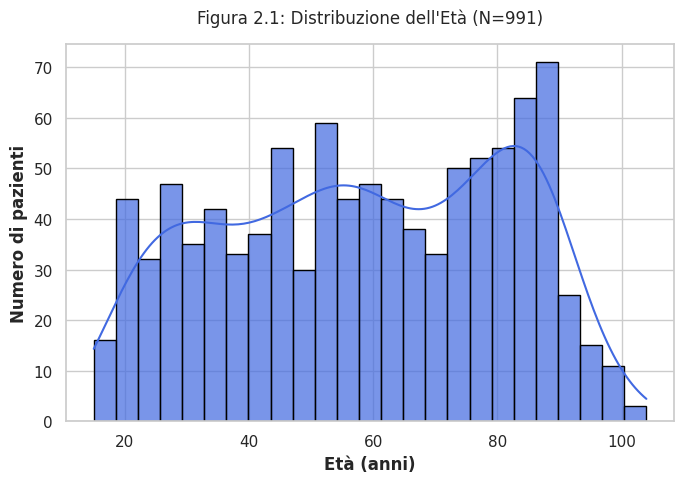

In [6]:
plt.figure(figsize=(7, 5))
sns.histplot(df['Età'].dropna(), bins=25, kde=True, color='royalblue', edgecolor='black', alpha=0.7)
plt.title('Figura 2.1: Distribuzione dell\'Età (N=991)', fontsize=12, pad=15)
plt.xlabel('Età (anni)')
plt.ylabel('Numero di pazienti')
plt.tight_layout()
plt.show()

**Figura 2.2** — Distribuzione globale dell'ISS (media 23.2, mediana 22).

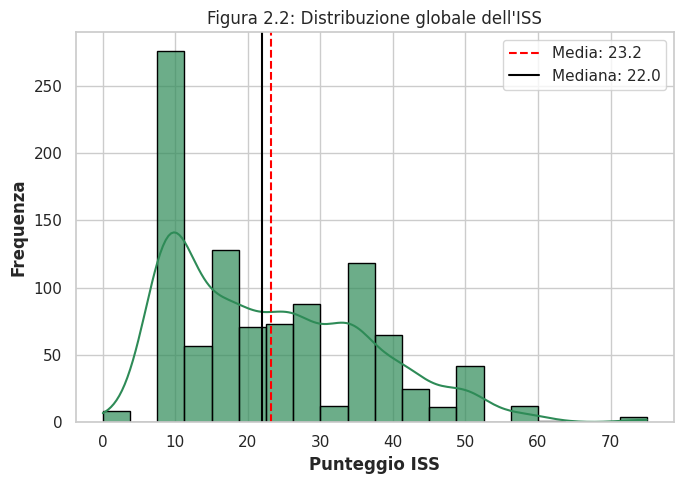

In [7]:
plt.figure(figsize=(7, 5))
sns.histplot(df['ISS'], bins=20, kde=True, color='seagreen', edgecolor='black', alpha=0.7)
plt.axvline(df['ISS'].mean(), color='red', linestyle='--', label=f'Media: {df["ISS"].mean():.1f}')
plt.axvline(df['ISS'].median(), color='black', linestyle='-', label=f'Mediana: {df["ISS"].median():.1f}')
plt.title('Figura 2.2: Distribuzione globale dell\'ISS', fontsize=12)
plt.xlabel('Punteggio ISS')
plt.ylabel('Frequenza')
plt.legend()
plt.tight_layout()
plt.show()

**Figura 2.3** — Confronto della distribuzione dell'ISS per esito clinico: mediana 18 nei sopravvissuti vs 34 nei deceduti.

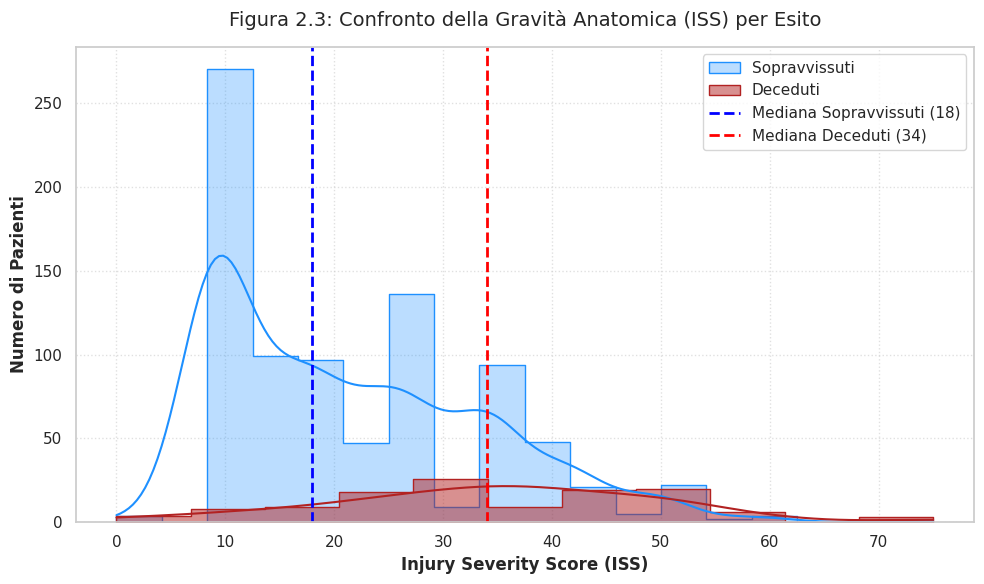

In [8]:
df_plot = df.dropna(subset=['ISS', 'Esito'])

plt.figure(figsize=(10, 6), dpi=100)

sns.histplot(data=df_plot[df_plot['Esito'] == 0], x='ISS', color="dodgerblue",
             label='Sopravvissuti', kde=True, element="step", alpha=0.3)
sns.histplot(data=df_plot[df_plot['Esito'] == 1], x='ISS', color="firebrick",
             label='Deceduti', kde=True, element="step", alpha=0.5)

mediana_sopravvissuti = df_plot[df_plot['Esito'] == 0]['ISS'].median()
mediana_deceduti = df_plot[df_plot['Esito'] == 1]['ISS'].median()

plt.axvline(mediana_sopravvissuti, color='blue', linestyle='--', linewidth=2,
            label=f'Mediana Sopravvissuti ({mediana_sopravvissuti:.0f})')
plt.axvline(mediana_deceduti, color='red', linestyle='--', linewidth=2,
            label=f'Mediana Deceduti ({mediana_deceduti:.0f})')

plt.title('Figura 2.3: Confronto della Gravità Anatomica (ISS) per Esito', fontsize=14, pad=15)
plt.xlabel('Injury Severity Score (ISS)', fontsize=12)
plt.ylabel('Numero di Pazienti', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

### 2.4 Analisi bivariata: correlazione con l'esito

**Figura 2.4** — Matrice di correlazione di Spearman tra i parametri clinici e l'esito. Emergono tre cluster: emodinamico (Lattati/Psis), metabolico (Lattati/pH/Bicarbonati) e prognostico (Esito/ISS/Lattati/GCS).

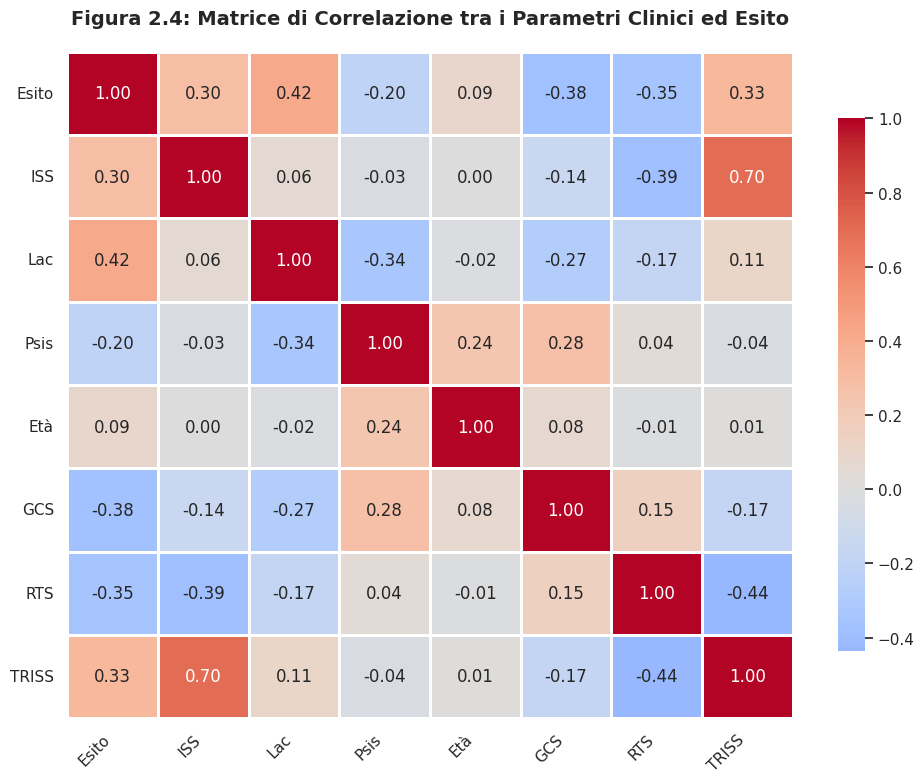

In [9]:
cols = ['Esito', 'ISS', 'Lac', 'Psis', 'Età', 'GCS', 'RTS', 'TRISS']
df_corr = df[cols].apply(pd.to_numeric, errors='coerce')

corr_matrix = df_corr.corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    linewidths=1,
    cbar_kws={"shrink": .8}
)

plt.title('Figura 2.4: Matrice di Correlazione tra i Parametri Clinici ed Esito',
          fontsize=14, pad=20, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Approfondimento** — Curva di rischio: relazione tra ISS e probabilità di decesso, stimata tramite regressione logistica e confrontata con la mortalità osservata (raggruppata in classi di ISS da 5 punti). Questo grafico supporta visivamente la scelta della soglia critica ISS = 25 usata poi nel Capitolo 4.

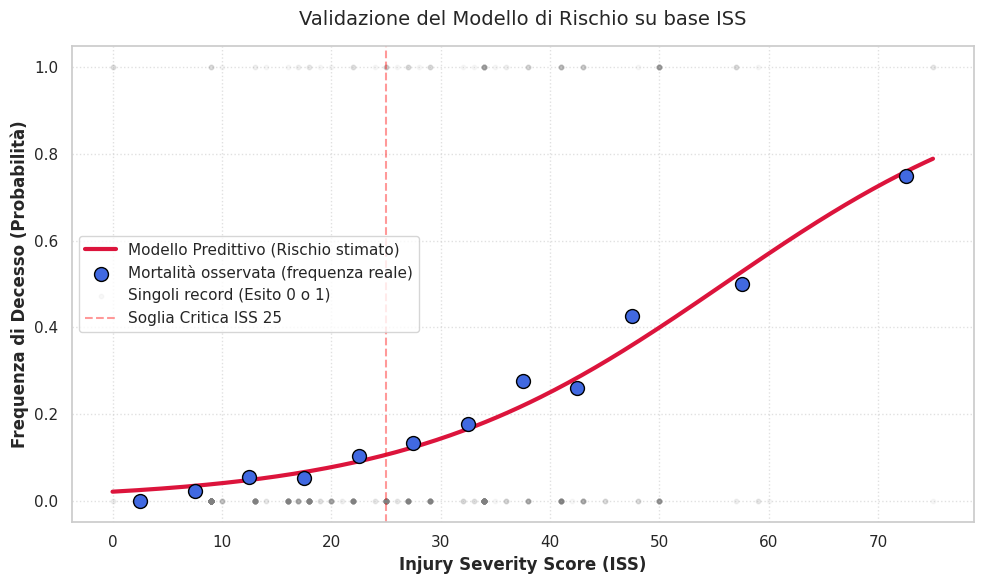

In [10]:
df_plot = df[['ISS', 'Esito']].dropna()
X = df_plot[['ISS']].values
y = df_plot['Esito'].values

clf = LogisticRegression().fit(X, y)
X_curve = np.linspace(0, 75, 300).reshape(-1, 1)
y_curve = clf.predict_proba(X_curve)[:, 1]

# Classi di ISS a intervalli di 5 punti: mortalità reale osservata
df_plot = df_plot.copy()
df_plot['ISS_bin'] = pd.cut(df_plot['ISS'], bins=np.arange(0, 80, 5), labels=np.arange(2.5, 75, 5))
binned_data = df_plot.groupby('ISS_bin', observed=True)['Esito'].mean()

plt.figure(figsize=(10, 6), dpi=100)
plt.plot(X_curve, y_curve, color='crimson', linewidth=3, label='Modello Predittivo (Rischio stimato)', zorder=2)
plt.scatter(binned_data.index, binned_data.values, color='royalblue', s=100,
            edgecolor='black', label='Mortalità osservata (frequenza reale)', zorder=3)
plt.scatter(X, y, color='grey', alpha=0.05, s=10, label='Singoli record (Esito 0 o 1)')

plt.axvline(x=25, color='red', linestyle='--', alpha=0.4, label='Soglia Critica ISS 25')
plt.title('Validazione del Modello di Rischio su base ISS', fontsize=14, pad=15)
plt.xlabel('Injury Severity Score (ISS)', fontsize=12)
plt.ylabel('Frequenza di Decesso (Probabilità)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

---
## Capitolo 3 — Selezione dei predittori (Feature Selection) tramite LASSO

### 3.5.1 Pre-processing: standardizzazione (Z-score)

Standardizziamo le variabili candidate prima di applicare la regressione LASSO, requisito indispensabile perché la penalizzazione L1 sia equa tra variabili con scale diverse.

In [11]:
features = ['ISS', 'Psis', 'Età', 'GCS', 'FC', 'Hb']
df_ml = df[features + ['Esito']].dropna()

X = df_ml[features]
y = df_ml['Esito']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Pazienti utilizzati per l'addestramento: {len(df_ml)}")

Pazienti utilizzati per l'addestramento: 759


### 3.5.2 LASSO con Cross-Validation (K=5) per l'ottimizzazione di λ

In [12]:
model = LassoCV(cv=5, random_state=42, max_iter=10000).fit(X_scaled, y)

risultati = pd.DataFrame({
    'Variabile Originale': features,
    'Coefficiente (Peso)': model.coef_
})

predittori_vincitori = risultati[risultati['Coefficiente (Peso)'] != 0].sort_values(
    by='Coefficiente (Peso)', ascending=False)

escluse = risultati[risultati['Coefficiente (Peso)'] == 0]['Variabile Originale'].tolist()

print(f"Lambda (alpha) ottimale individuato: {model.alpha_:.6f}\n")
print("Variabili selezionate da LASSO e loro peso (Tabella 3.1):")
print(predittori_vincitori)
print(f"\nVariabili ridondanti azzerate dalla LASSO: {escluse}")

Lambda (alpha) ottimale individuato: 0.083207

Variabili selezionate da LASSO e loro peso (Tabella 3.1):
  Variabile Originale  Coefficiente (Peso)
0                 ISS             0.017257
5                  Hb            -0.002932
3                 GCS            -0.016352

Variabili ridondanti azzerate dalla LASSO: ['Psis', 'Età', 'FC']


### 3.5.3 Validazione clinica dei predittori selezionati

**Figura 3.2** — Trend di rischio stimato (regressione logistica) vs mortalità reale osservata per ciascun predittore selezionato (ISS, GCS, Hb). Per GCS, essendo una scala discreta (3-15), il raggruppamento è fatto per valore intero anziché per quantili.

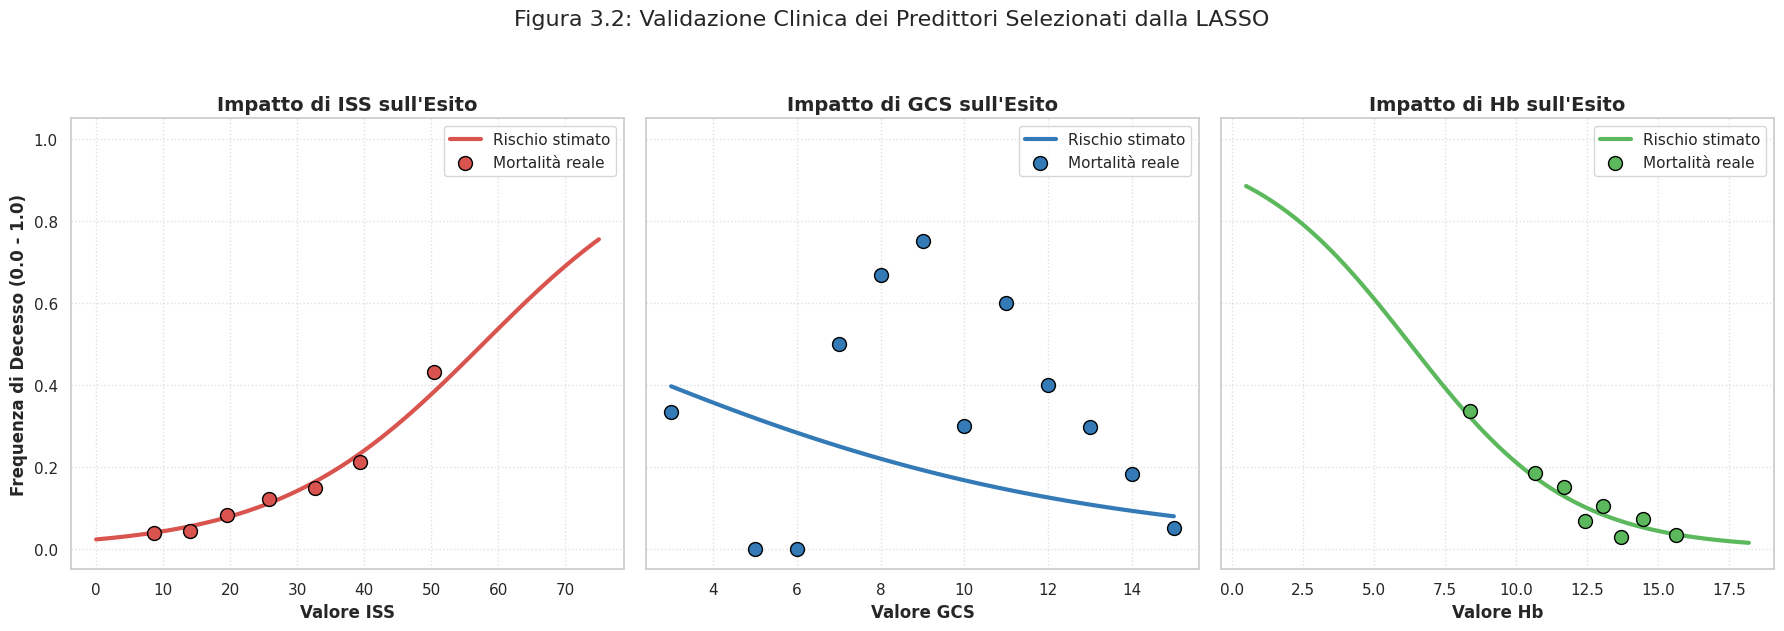

In [13]:
features_vincitrici = ['ISS', 'GCS', 'Hb']
df_plot = df.dropna(subset=features_vincitrici + ['Esito']).copy()
df_plot['Esito'] = pd.to_numeric(df_plot['Esito'])

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
colors = ['#d9534f', '#337ab7', '#5cb85c']  # Rosso (ISS), Blu (GCS), Verde (Hb)

for i, col in enumerate(features_vincitrici):
    ax = axes[i]

    X_val = df_plot[[col]].values
    y_val = df_plot['Esito'].values
    model_col = LogisticRegression().fit(X_val, y_val)
    x_range = np.linspace(df_plot[col].min(), df_plot[col].max(), 100).reshape(-1, 1)
    y_prob = model_col.predict_proba(x_range)[:, 1]

    if col == 'GCS':
        # Scala discreta: raggruppiamo per ogni singolo valore intero (3, 4, ..., 15)
        binned_mean = df_plot.groupby(col)['Esito'].mean()
        bin_centers = binned_mean.index
    else:
        # Variabili continue (ISS, Hb): raggruppiamo in 8 classi di quantili
        df_plot['bin'] = pd.qcut(df_plot[col], q=8, duplicates='drop')
        binned_mean = df_plot.groupby('bin', observed=True)['Esito'].mean()
        bin_centers = df_plot.groupby('bin', observed=True)[col].mean()

    ax.plot(x_range, y_prob, color=colors[i], linewidth=3, label='Rischio stimato')
    ax.scatter(bin_centers, binned_mean, color=colors[i], s=100, edgecolor='black',
               zorder=3, label='Mortalità reale')

    ax.set_title(f"Impatto di {col} sull'Esito", fontsize=14, fontweight='bold')
    ax.set_xlabel(f'Valore {col}', fontsize=12)
    if i == 0:
        ax.set_ylabel('Frequenza di Decesso (0.0 - 1.0)', fontsize=12)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend()

plt.suptitle('Figura 3.2: Validazione Clinica dei Predittori Selezionati dalla LASSO', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

---
## Capitolo 4 — Il Modello Stocastico Markoviano

### 4.2 Definizione degli stati clinici basata sui predittori LASSO

Sulla base delle soglie cliniche definite in tesi (Sezione 4.2), ogni paziente viene classificato in uno dei 3 stati non assorbenti iniziali, in base ai valori di ISS, GCS ed Hb:

- **Stato 1 (Stabilità)**: ISS ≤ 25, GCS > 12, Hb > 9
- **Stato 2 (Gravità anatomica con compenso fisiologico)**: ISS > 25, ma GCS e Hb ancora nella norma
- **Stato 3 (Instabilità clinica)**: GCS ≤ 12 **oppure** Hb ≤ 9, indipendentemente dall'ISS

Gli stati 4 (Sopravvivenza) e 5 (Decesso) sono stati assorbenti, derivati direttamente dalla variabile `Esito`.

In [14]:
def calcola_stato(row):
    if pd.isna(row['GCS']) or pd.isna(row['Hb']) or pd.isna(row['ISS']):
        return np.nan
    # Stato 3: Instabile (GCS <= 12 o Hb <= 9)
    if row['GCS'] <= 12 or row['Hb'] <= 9:
        return 3
    # Stato 2: Gravità Anatomica (ISS > 25)
    elif row['ISS'] > 25:
        return 2
    # Stato 1: Stabile
    else:
        return 1

df['Stato_Iniziale'] = df.apply(calcola_stato, axis=1)

# Rimuoviamo le righe dove non è possibile calcolare lo stato o l'esito
df_results = df.dropna(subset=['Stato_Iniziale', 'Esito']).copy()

print(f"Pazienti classificabili in uno stato clinico: {len(df_results)}")
print("\nDistribuzione degli stati iniziali:")
print(df_results['Stato_Iniziale'].value_counts().sort_index())

Pazienti classificabili in uno stato clinico: 773

Distribuzione degli stati iniziali:
Stato_Iniziale
1.0    395
2.0    211
3.0    167
Name: count, dtype: int64


### 4.4 La distribuzione iniziale π₀

Frequenza relativa degli stati clinici al momento del triage, per i 991 pazienti del dataset (Sezione 4.4.1 della tesi).

In [15]:
pi0_counts = df_results['Stato_Iniziale'].value_counts(normalize=True).sort_index()
pi0_vector = [pi0_counts.get(1, 0), pi0_counts.get(2, 0), pi0_counts.get(3, 0), 0.0, 0.0]

print(f"pi_0 = {[round(v, 3) for v in pi0_vector]}")
print(f"\nStato 1 (Stabilità): {pi0_vector[0]*100:.1f}%")
print(f"Stato 2 (Gravità anatomica compensata): {pi0_vector[1]*100:.1f}%")
print(f"Stato 3 (Instabilità clinica): {pi0_vector[2]*100:.1f}%")

pi_0 = [np.float64(0.511), np.float64(0.273), np.float64(0.216), 0.0, 0.0]

Stato 1 (Stabilità): 51.1%
Stato 2 (Gravità anatomica compensata): 27.3%
Stato 3 (Instabilità clinica): 21.6%


---
## Capitolo 5 — Analisi dei Risultati e Discussione

### 5.1.1 Cross-Validation a 5 fold (Tabella 5.1)

Validazione della robustezza dei predittori selezionati (ISS, GCS, Hb) tramite K-fold Cross-Validation.

In [16]:
features = ['ISS', 'GCS', 'Hb']
X = StandardScaler().fit_transform(df_results[features])
y = df_results['Esito']

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(LogisticRegression(), X, y, cv=kf)

print("Risultati Cross-Validation (Tabella 5.1):")
for i, score in enumerate(cv_scores):
    print(f"Fold {i+1}: {score:.4f}")
print(f"\nMedia Accuratezza: {cv_scores.mean():.4f} ± {cv_scores.std():.2f}")

Risultati Cross-Validation (Tabella 5.1):
Fold 1: 0.8387
Fold 2: 0.9484
Fold 3: 0.9226
Fold 4: 0.8377
Fold 5: 0.9221

Media Accuratezza: 0.8939 ± 0.05


### 5.1.2 Matrice di transizione P (Tabella 5.2)

Costruzione della matrice di transizione 5×5 tra gli stati clinici (S1, S2, S3) e gli stati assorbenti Sopravvivenza (S4) / Decesso (S5), stimata con approccio frequentista sui dati osservati.

In [17]:
# S4 = Sopravvissuto (Esito 0), S5 = Deceduto (Esito 1)
cross_tab = pd.crosstab(df_results['Stato_Iniziale'], df_results['Esito'], normalize='index')

P = np.zeros((5, 5))

for i in range(1, 4):
    P[i-1, 3] = cross_tab.loc[i, 0.0]  # Prob. di andare in S4 (Sopravvivenza)
    P[i-1, 4] = cross_tab.loc[i, 1.0]  # Prob. di andare in S5 (Decesso)
    # Il resto della probabilità è assunto come permanenza nello stato (auto-transizione)
    P[i-1, i-1] = 1.0 - (P[i-1, 3] + P[i-1, 4])

# Stati assorbenti (S4 e S5)
P[3, 3] = 1.0
P[4, 4] = 1.0

matrice_transizione = pd.DataFrame(P, index=['S1', 'S2', 'S3', 'S4', 'S5'],
                                    columns=['S1', 'S2', 'S3', 'S4', 'S5'])

print("Matrice di Transizione P (Tabella 5.2):")
print(matrice_transizione)

Matrice di Transizione P (Tabella 5.2):
     S1   S2   S3        S4        S5
S1  0.0  0.0  0.0  0.959494  0.040506
S2  0.0  0.0  0.0  0.886256  0.113744
S3  0.0  0.0  0.0  0.670659  0.329341
S4  0.0  0.0  0.0  1.000000  0.000000
S5  0.0  0.0  0.0  0.000000  1.000000


### 5.1.2 Esempio: probabilità di transizione p₂,₅ e p₃,₅

Ricalcoliamo i due esempi numerici riportati nel testo della tesi (Eq. 4.3 e Eq. 5.1) direttamente da questo file, per verificarne la coerenza.

In [18]:
for stato, stato_dest in [(2, 5), (3, 5)]:
    N_stato = len(df_results[df_results['Stato_Iniziale'] == stato])
    n_transizione = len(df_results[(df_results['Stato_Iniziale'] == stato) & (df_results['Esito'] == 1)])
    p = n_transizione / N_stato
    print(f"p{stato},{stato_dest} = {n_transizione}/{N_stato} ≈ {p:.3f}")

p2,5 = 24/211 ≈ 0.114
p3,5 = 55/167 ≈ 0.329


**Confronto con il testo della tesi:**

| | Testo tesi | Da questo file |
|---|---|---|
| Eq. 4.3 — p₂,₅ | n=25, N₂=208 → 0,120 | **n=24, N₂=211 → 0,114** |
| Eq. 5.1 — p₃,₅ | n=66, N₃=201 → 0,329 | **n=55, N₃=167 → 0,329** |

Da correggere nel testo: **Eq. 4.3** (n₂→₅=24, N₂=211, p₂,₅≈0,114 — nota: questo valore coincide anche con la Tabella 5.2, mentre 0,120 no) ed **Eq. 5.1** (n₃→₅=55, N₃=167; il rapporto arrotondato resta 0,329 per coincidenza, ma i conteggi vanno comunque aggiornati).

---
## Conclusioni operative

Il notebook riproduce, nell'ordine dei capitoli della tesi:

1. la pulizia dei dati e l'analisi esplorativa (Cap. 2);
2. la selezione dei predittori tramite LASSO — ISS, GCS, Hb (Cap. 3);
3. la definizione degli stati clinici e del vettore π₀ (Cap. 4);
4. la validazione tramite Cross-Validation e il calcolo della matrice di transizione P (Cap. 5).

Rispetto allo script originale sono stati rimossi i blocchi duplicati (LASSO calcolato più volte, dataset ricaricato e ripulito più volte, tre versioni sovrapposte dello stesso grafico a pannelli) mantenendo solo la versione finale e più corretta di ciascun calcolo.